In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import k_fold_cross_validation
from src.config import Paths, ModelConfig

In [2]:
df = pd.read_csv(Paths.encoded_data)

DURATION_COL = ModelConfig.duration_col
EVENT_COL = ModelConfig.event_col

print(df.shape)
df.head()

(7043, 17)


,Age,Number_of_Dependents,Number_of_Referrals,Tenure_in_Months,Avg_Monthly_Long_Distance_Charges,Avg_Monthly_GB_Download,Num_Internet_Features,Has_Multiple_Lines,Churn_status,gender_e,married_e,paper_e,offer_e,Contract_e,Payment_Method_e,Internet_Type_DSL,Internet_Type_Fiber Optic
0,37,0,2,9,42.39,16.0,5,1,0,0,1,1,0,1,1,0,0
1,46,0,0,9,10.69,10.0,3,2,0,1,0,0,0,0,1,0,0
2,50,0,0,4,33.65,30.0,3,1,1,1,0,1,1,0,0,0,1
3,78,0,1,13,27.82,4.0,6,1,1,1,1,1,1,0,0,0,1
4,75,0,3,3,7.38,11.0,4,1,1,0,1,1,0,0,1,0,1


In [3]:
# Drop same skewed columns as AFT for consistency
df = df.drop(columns=[c for c in ModelConfig.cols_to_drop if c in df.columns])
df.columns.tolist()

['Age',
 'Tenure_in_Months',
 'Churn_status',
 'gender_e',
 'married_e',
 'paper_e',
 'offer_e',
 'Contract_e',
 'Payment_Method_e',
 'Internet_Type_Fiber Optic']

Proportionality assumption check (KM curves)

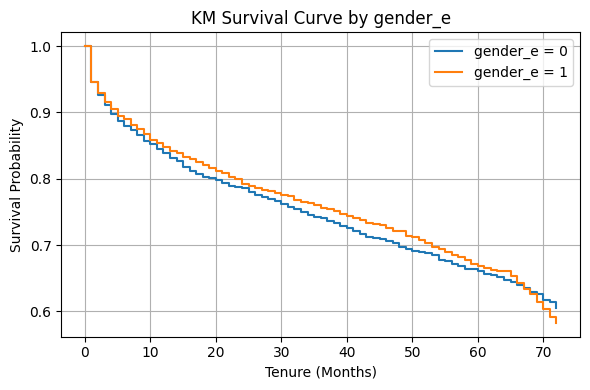

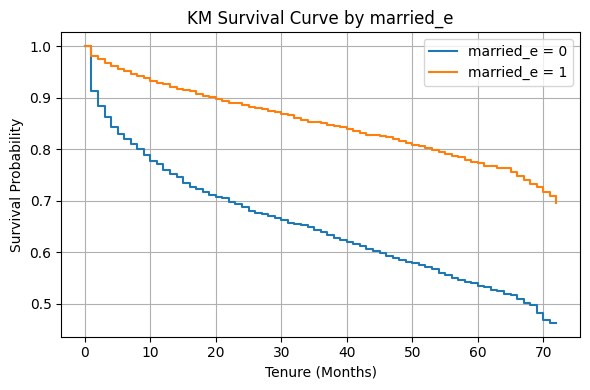

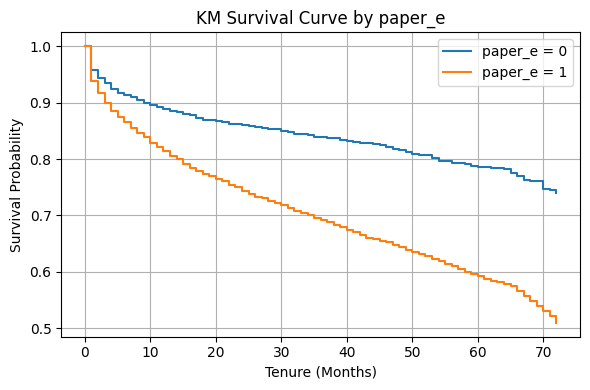

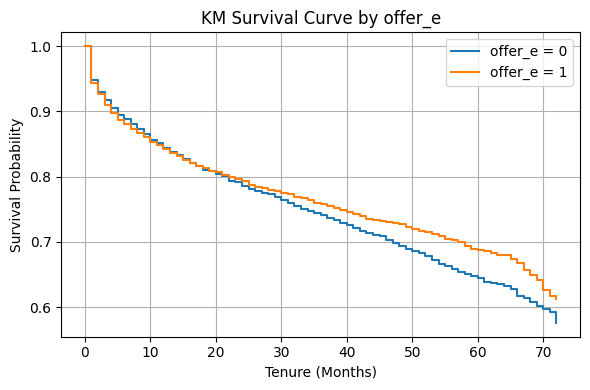

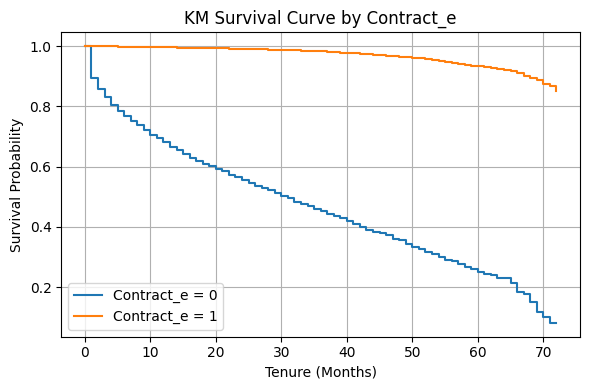

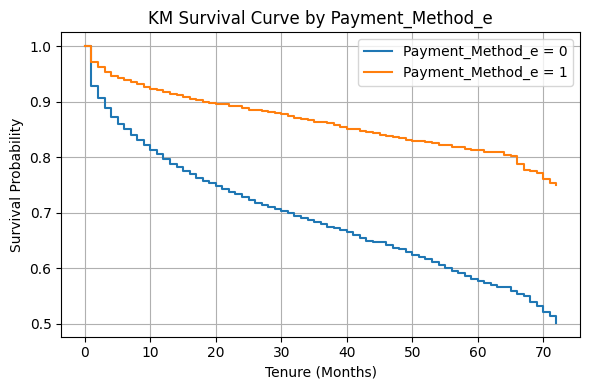

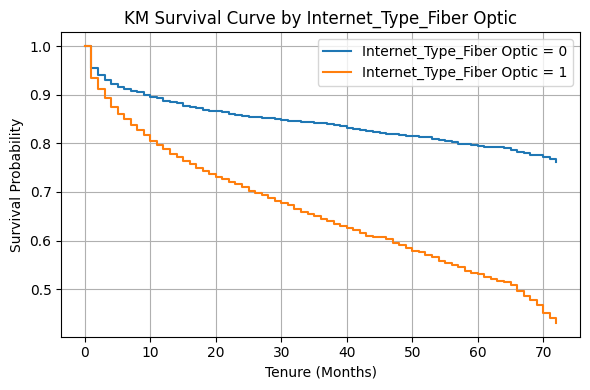

In [4]:
categorical_vars = [
    'gender_e', 'married_e', 'paper_e', 'offer_e',
    'Contract_e', 'Payment_Method_e', 'Internet_Type_Fiber Optic'
]

T = df[DURATION_COL]
E = df[EVENT_COL]

for var in categorical_vars:
    plt.figure(figsize=(6, 4))
    kmf = KaplanMeierFitter()
    for group in sorted(df[var].dropna().unique()):
        ix = df[var] == group
        kmf.fit(T[ix], event_observed=E[ix], label=f"{var} = {group}")
        kmf.plot(ci_show=False)
    plt.title(f"KM Survival Curve by {var}")
    plt.xlabel("Tenure (Months)")
    plt.ylabel("Survival Probability")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Proportionality Takeaways

- `Contract_e` and `Internet_Type_Fiber Optic` show non-parallel curves
  → violate proportional hazards → handled via **stratification**
- `offer_e` shows time-varying effect (offer impact fades with tenure)
  → handled via **time interaction term** `offer_log`
- `gender_e`, `married_e`, `paper_e`, `Payment_Method_e` → assumption holds

Add time-varying covariate

In [5]:
df['offer_log'] = df['offer_e'] * np.log(df[DURATION_COL] + 1)

Fit Stratified Cox model

In [6]:
COX_COLS = [
    'Age', 'gender_e', 'married_e', 'paper_e',
    'offer_e', 'offer_log', 'Payment_Method_e',
    'Contract_e', 'Internet_Type_Fiber Optic',
    DURATION_COL, EVENT_COL
]

cph = CoxPHFitter()
cph.fit(
    df[COX_COLS],
    duration_col=DURATION_COL,
    event_col=EVENT_COL,
    strata=['Contract_e', 'Internet_Type_Fiber Optic']
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure_in_Months'
                event col = 'Churn_status'
                   strata = ['Contract_e', 'Internet_Type_Fiber Optic']
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -11905.54
         time fit was run = 2026-04-19 20:23:51 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
Age               0.01      1.01      0.00            0.01            0.01                1.01                1.01
gender_e         -0.04      0.96      0.05           -0.13            0.05                0.88                1.05
married_e        -0.51      0.60      0.05           -0.61           -0.41                0.54                0.67
paper_e           0.23      1.26      0.06            0.12            0.34                1.13                1.40
offer_e           3.91     49.80      0.12            3.66            4.15               39.03               63.55
offer_log        -1.32      0.27      0.04           -1.40           -1.24                0.25                0.29
Payment_Method_e -0.48      0.62      0.06           -0.59           -0.36                0.55                0.69

                  cmp to      z      p  -log2(p)
covariate                                       
Age                 0.00   6.48 <0.005     33.30
gender_e            0.00  -0.83   0.41      1.29
married_e           0.00  -9.85 <0.005     73.64
paper_e             0.00   4.14 <0.005     14.82
offer_e             0.00  31.43 <0.005    717.91
offer_log           0.00 -32.23 <0.005    754.87
Payment_Method_e    0.00  -8.26 <0.005     52.61
---
Concordance = 0.75
Partial AIC = 23825.09
log-likelihood ratio test = 1438.64 on 7 df
-log2(p) of ll-ratio test = 1015.76

Cross-validated C-index

In [7]:
cv_scores = k_fold_cross_validation(
    cph, df[COX_COLS],
    duration_col=DURATION_COL,
    event_col=EVENT_COL,
    k=5,
    scoring_method="concordance_index"
)

print(f"Cox CV C-index (mean): {np.mean(cv_scores):.3f}")
print(f"Individual folds: {np.round(cv_scores, 3)}")
print(f"\nAFT C-index: ~0.83 | Cox C-index: ~{np.mean(cv_scores):.2f}")
print("→ AFT selected for production (higher C-index + direct time prediction)")

g:\My Drive\1 - Projects\Survival Analysis - Advanced Python Project\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
g:\My Drive\1 - Projects\Survival Analysis - Advanced Python Project\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
g:\My Drive\1 - Projects\Survival Analysis - Advanced Python Project\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
g:\My Drive\1 - Projects\Survival Analysis - Advanced Python Project\.venv\Lib\site-pack

Cox CV C-index (mean): 0.817
Individual folds: [0.827 0.815 0.809 0.835 0.797]

AFT C-index: ~0.83 | Cox C-index: ~0.82
→ AFT selected for production (higher C-index + direct time prediction)


g:\My Drive\1 - Projects\Survival Analysis - Advanced Python Project\.venv\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


Survival curve comparison across customer profiles

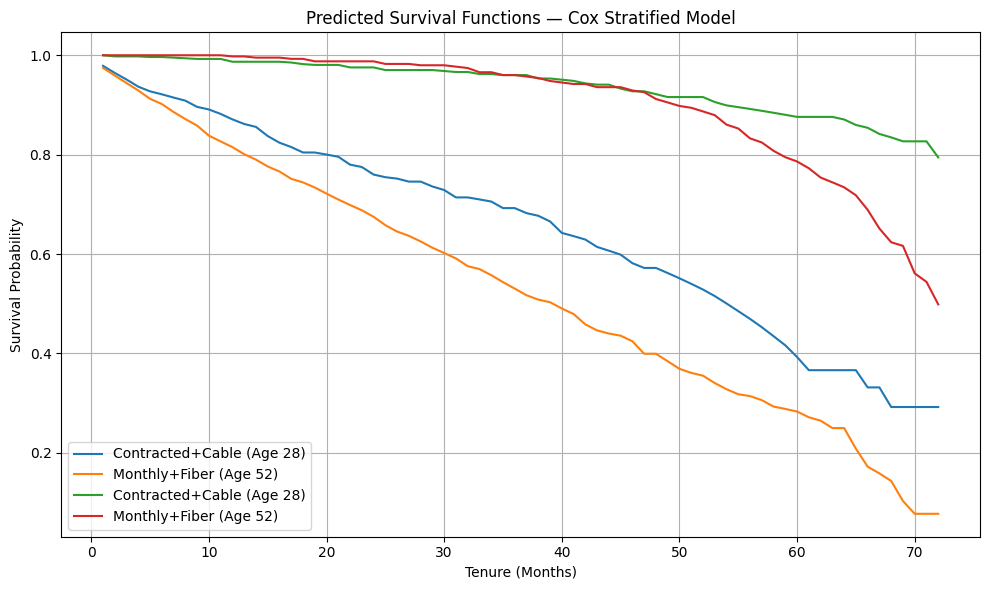

In [8]:
profiles = pd.DataFrame({
    'Age':                        [28, 52, 28, 52],
    'gender_e':                   [1,  0,  1,  0],
    'married_e':                  [0,  1,  0,  1],
    'paper_e':                    [1,  1,  1,  1],
    'offer_e':                    [1,  1,  1,  1],
    'Payment_Method_e':           [1,  0,  1,  0],
    'Contract_e':                 [1,  0,  1,  0],
    'Internet_Type_Fiber Optic':  [1,  0,  0,  1],
    DURATION_COL:                 [12, 24, 12, 24],
})
profiles['offer_log'] = profiles['offer_e'] * np.log(profiles[DURATION_COL] + 1)

survival_fns = cph.predict_survival_function(profiles)

labels = [
    f"Contracted+Cable (Age {profiles['Age'].iloc[i]})" 
    if profiles['Contract_e'].iloc[i] == 1 
    else f"Monthly+Fiber (Age {profiles['Age'].iloc[i]})"
    for i in range(len(profiles))
]

plt.figure(figsize=(10, 6))
for i, label in enumerate(labels):
    plt.plot(survival_fns.index, survival_fns.iloc[:, i], label=label)
plt.title("Predicted Survival Functions — Cox Stratified Model")
plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()